# IBM Quantum validation of a noncanonical two-component GHZ resource

This notebook extends the receiver-tomography experiment to the noncanonical resource
member $(M_1,M_2)=(0,1)$ of the four-member family in the manuscript.

The resource prepared on $(q_4,q_3,q_2)$ is

$$
|G_{m;0,1}\rangle=
\frac{|100\rangle+(-1)^m|011\rangle}{\sqrt{2}}
=X_4|G_m\rangle.
$$

Its resource-induced receiver factor is $XZ$ on $q_3$. The full raw frame in receiver
order $(q_4,q_3)$ is

$$
C_{x,m}^{(0,1)}=X_4^{m\oplus x}\otimes X_3^{m\oplus1}Z_3,
$$

and the physical inverse recovery is

$$
C_{x,m}^{(0,1)\dagger}=X_4^{m\oplus x}\otimes Z_3X_3^{m\oplus1}.
$$

The same nonsymmetric complex input is used for all four $(x,m)$ cases:

$$
|\chi_0\rangle=\sqrt{0.7}|00\rangle+e^{i\pi/3}\sqrt{0.3}|11\rangle.
$$

For each case, the notebook reconstructs the raw receiver, the software-frame-tracked
receiver, and the receiver after explicit physical recovery. All figure labels, table
headings, filenames, and saved outputs are in English.

## 1. Install the required packages

Run this cell once. If imports fail immediately after installation, restart the kernel
and continue from Section 2.

In [1]:
%pip install --upgrade "qiskit[visualization]>=2.5,<3" "qiskit-aer>=0.17,<1" "qiskit-ibm-runtime>=0.47,<1" "pandas>=2,<4" "seaborn>=0.13,<1"

Note: you may need to restart the kernel to use updated packages.


## 2. Imports and experiment configuration

In [2]:
import json
import platform
from collections import Counter
from datetime import datetime, timezone
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import qiskit
import qiskit_aer
import qiskit_ibm_runtime

from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister, transpile
from qiskit.quantum_info import DensityMatrix, Statevector, partial_trace
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as RuntimeSampler

print("Python:", platform.python_version())
print("Qiskit:", qiskit.__version__)
print("Qiskit Aer:", qiskit_aer.__version__)
print("Qiskit IBM Runtime:", qiskit_ibm_runtime.__version__)

Python: 3.12.11
Qiskit: 2.5.2
Qiskit Aer: 0.17.2
Qiskit IBM Runtime: 0.49.0


In [3]:
# Manuscript input state, selected resource member, and hardware settings.
INPUT_PROBABILITY_00 = 0.7
INPUT_PHASE = np.pi / 3
Y_SECTOR = 0

RESOURCE_M1 = 0
RESOURCE_M2 = 1
RESOURCE_LABEL = f"M1={RESOURCE_M1}, M2={RESOURCE_M2}"
CASES = [(0, 0), (1, 0), (0, 1), (1, 1)]

LOCAL_SHOTS = 4096
HARDWARE_SHOTS = 4096
HARDWARE_REPEATS = 1
BOOTSTRAP_SAMPLES = 500
RANDOM_SEED = 240917

OUTPUT_DIR = Path.cwd() / "noncanonical_resource_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Selected resource:", RESOURCE_LABEL)
print("Output directory:", OUTPUT_DIR.resolve())

Selected resource: M1=0, M2=1
Output directory: C:\Users\hideok34\noncanonical_resource_results


## 3. Five-qubit circuit and family-wide deterministic recovery

The source state is prepared independently of the circuit-control bit $x$. The selected
resource is prepared by applying $X^{M_1}$ to $q_3$ and $X^{M_2}$ to $q_4$ before the two
GHZ-entangling CNOT gates.

Define $z=m\oplus x$ and $k=m\oplus M_1\oplus M_2$. In receiver order $(q_4,q_3)$,
the predicted raw frame is

$$C_{x,m}^{(M_1,M_2)}=X^z\otimes X^kZ^{M_2}.$$

The appended gate order on $q_3$ is first $X^k$, then $Z^{M_2}$, which implements the
inverse $Z^{M_2}X^k$ because later circuit gates multiply from the left. Reversing the
two Pauli gates changes only an overall phase, but this notebook follows the inverse
written in the manuscript.

In [4]:
def prepare_logical_input(circuit, qubits, state_label="custom", y=Y_SECTOR):
    # Prepare a logical state on (q1,q0), with ket order |q1 q0>.
    q0, q1 = qubits[0], qubits[1]

    if state_label == "custom":
        theta = 2 * np.arccos(np.sqrt(INPUT_PROBABILITY_00))
        circuit.ry(theta, q0)
        circuit.p(INPUT_PHASE, q0)
    elif state_label == "zero":
        pass
    elif state_label == "one":
        circuit.x(q0)
    elif state_label == "plus":
        circuit.h(q0)
    elif state_label == "plus_i":
        circuit.h(q0)
        circuit.s(q0)
    else:
        raise ValueError(f"Unknown logical input: {state_label}")

    if y:
        circuit.x(q1)
    circuit.cx(q0, q1)


def prepare_ghz_resource(circuit, qubits, m, M1=RESOURCE_M1, M2=RESOURCE_M2):
    # Prepare (|M2,M1,0> + (-1)^m |not M2,not M1,1>)/sqrt(2).
    q2, q3, q4 = qubits[2], qubits[3], qubits[4]
    if m:
        circuit.x(q2)
    circuit.h(q2)
    if M1:
        circuit.x(q3)
    if M2:
        circuit.x(q4)
    circuit.cx(q2, q3)
    circuit.cx(q2, q4)


def append_transfer_network(circuit, qubits, x, m):
    # Append the coherent transfer network of manuscript Figure 4.
    q0, q1, q2, q3, q4 = qubits
    z = m ^ x

    circuit.barrier()
    circuit.h(q1)
    circuit.cx(q1, q2)
    circuit.h(q1)
    circuit.cx(q2, q3)

    circuit.barrier()
    circuit.h(q3)
    if m:
        circuit.x(q3)
    circuit.cx(q1, q3)
    circuit.h(q3)
    if m:
        circuit.x(q3)

    circuit.barrier()
    circuit.cx(q2, q4)
    circuit.cx(q4, q3)

    circuit.barrier()
    circuit.cx(q0, q3)
    circuit.h(q4)
    if z:
        circuit.x(q4)
    circuit.cx(q4, q0)
    circuit.barrier()


def append_receiver_recovery(
    circuit, qubits, x, m, M1=RESOURCE_M1, M2=RESOURCE_M2
):
    # Append X_4^z tensor Z_3^M2 X_3^k, where k=m xor M1 xor M2.
    q3, q4 = qubits[3], qubits[4]
    z = m ^ x
    k = m ^ M1 ^ M2
    if z:
        circuit.x(q4)
    if k:
        circuit.x(q3)
    if M2:
        circuit.z(q3)
    circuit.barrier()


def build_transfer_circuit(
    x,
    m,
    recovered=False,
    state_label="custom",
    M1=RESOURCE_M1,
    M2=RESOURCE_M2,
):
    q = QuantumRegister(5, "q")
    mode = "recovered" if recovered else "raw"
    name = f"M1{M1}_M2{M2}_x{x}_m{m}_{state_label}_{mode}"
    circuit = QuantumCircuit(q, name=name)
    prepare_logical_input(circuit, q, state_label=state_label)
    prepare_ghz_resource(circuit, q, m=m, M1=M1, M2=M2)
    append_transfer_network(circuit, q, x=x, m=m)
    if recovered:
        append_receiver_recovery(circuit, q, x=x, m=m, M1=M1, M2=M2)
    return circuit


I2 = np.eye(2, dtype=complex)
X2 = np.array([[0, 1], [1, 0]], dtype=complex)
Y2 = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z2 = np.array([[1, 0], [0, -1]], dtype=complex)
PAULI = {"I": I2, "X": X2, "Y": Y2, "Z": Z2}
TOMOGRAPHY_BASES = ("X", "Y", "Z")


def input_ket(state_label="custom"):
    if state_label == "custom":
        alpha = np.sqrt(INPUT_PROBABILITY_00)
        beta = np.exp(1j * INPUT_PHASE) * np.sqrt(1 - INPUT_PROBABILITY_00)
        return np.array([alpha, 0, 0, beta], dtype=complex)
    logical_vectors = {
        "zero": np.array([1, 0], dtype=complex),
        "one": np.array([0, 1], dtype=complex),
        "plus": np.array([1, 1], dtype=complex) / np.sqrt(2),
        "plus_i": np.array([1, 1j], dtype=complex) / np.sqrt(2),
    }
    logical = logical_vectors[state_label]
    return np.array([logical[0], 0, 0, logical[1]], dtype=complex)


def receiver_frame(x, m, M1=RESOURCE_M1, M2=RESOURCE_M2):
    z = m ^ x
    k = m ^ M1 ^ M2
    q4_factor = X2 if z else I2
    q3_factor = (X2 if k else I2) @ (Z2 if M2 else I2)
    return np.kron(q4_factor, q3_factor)


def pure_state_fidelity(rho, ket):
    value = np.real(np.vdot(ket, rho @ ket))
    return float(np.clip(value, 0.0, 1.0))

In [5]:
# Ideal statevector verification before any hardware job is submitted.
ideal_rows = []
target = input_ket("custom")

for x, m in CASES:
    frame = receiver_frame(x, m)
    for recovered in (False, True):
        circuit = build_transfer_circuit(x, m, recovered=recovered)
        full_state = Statevector.from_instruction(circuit)
        receiver_state = partial_trace(full_state, [0, 1, 2]).data
        expected = target if recovered else frame @ target
        fidelity = pure_state_fidelity(receiver_state, expected)
        ideal_rows.append(
            {
                "M1": RESOURCE_M1,
                "M2": RESOURCE_M2,
                "x": x,
                "m": m,
                "mode": "Recovered" if recovered else "Raw",
                "fidelity_to_theoretical_state": fidelity,
            }
        )
        if not np.isclose(fidelity, 1.0, atol=1e-10):
            raise AssertionError(
                f"Ideal verification failed for M1={RESOURCE_M1}, M2={RESOURCE_M2}, "
                f"x={x}, m={m}, recovered={recovered}: fidelity={fidelity}"
            )

ideal_verification = pd.DataFrame(ideal_rows)
display(ideal_verification)
print("All ideal receiver states match the family-wide channel theorem.")

,M1,M2,x,m,mode,fidelity_to_theoretical_state
0,0,1,0,0,Raw,1.0
1,0,1,0,0,Recovered,1.0
2,0,1,1,0,Raw,1.0
3,0,1,1,0,Recovered,1.0
4,0,1,0,1,Raw,1.0
5,0,1,0,1,Recovered,1.0
6,0,1,1,1,Raw,1.0
7,0,1,1,1,Recovered,1.0


All ideal receiver states match the family-wide channel theorem.


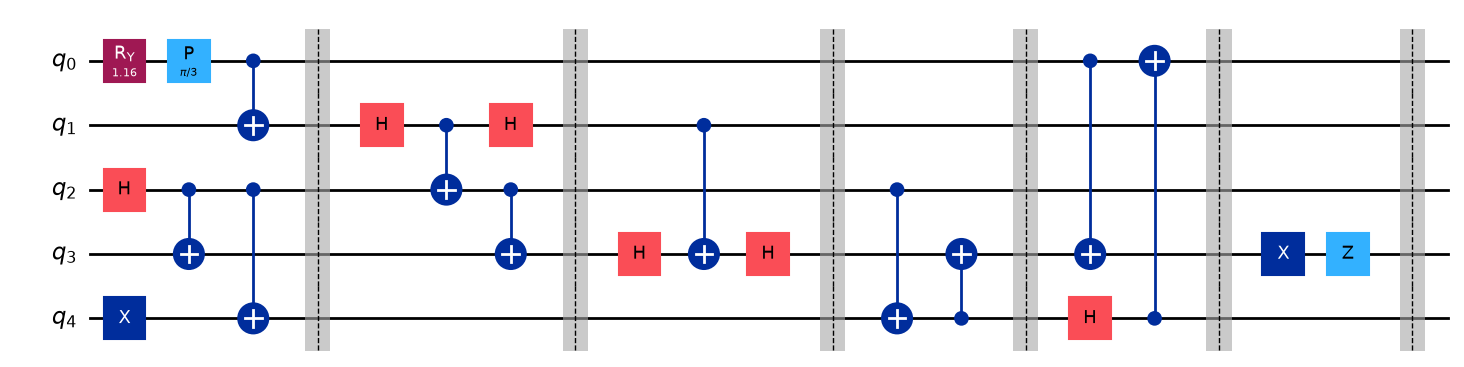

In [6]:
# Draw the noncanonical XZ case with x=0 and m=0.
build_transfer_circuit(0, 0, recovered=True).draw(
    output="mpl", fold=-1, idle_wires=False
)

## 4. Receiver-state tomography for the noncanonical resource

Each receiver state uses the nine local Pauli settings
$XX,XY,XZ,YX,YY,YZ,ZX,ZY,ZZ$. The measurement register is written as `q4 q3`,
matching the manuscript receiver ordering.

The reconstruction uses linear inversion followed by the nearest positive-semidefinite,
trace-one projection in Frobenius norm. Uncertainty intervals are multinomial bootstrap
intervals. Full tomography is essential here because the $Z$ component changes phase and
cannot be certified from computational-basis populations alone.

In [7]:
def append_basis_measurement(circuit, basis_q4, basis_q3):
    measured = circuit.copy()
    q3, q4 = measured.qubits[3], measured.qubits[4]

    for qubit, basis in ((q4, basis_q4), (q3, basis_q3)):
        if basis == "X":
            measured.h(qubit)
        elif basis == "Y":
            measured.sdg(qubit)
            measured.h(qubit)
        elif basis != "Z":
            raise ValueError(f"Unsupported basis: {basis}")

    meas = ClassicalRegister(2, "meas")
    measured.add_register(meas)
    measured.measure(q3, meas[0])
    measured.measure(q4, meas[1])
    return measured


def build_state_tomography_experiments():
    records = []
    circuits = []
    for x, m in CASES:
        for recovered in (False, True):
            mode = "recovered" if recovered else "raw"
            base = build_transfer_circuit(x, m, recovered=recovered)
            for basis_q4, basis_q3 in product(TOMOGRAPHY_BASES, repeat=2):
                circuit = append_basis_measurement(base, basis_q4, basis_q3)
                circuit.name = (
                    f"M1{RESOURCE_M1}_M2{RESOURCE_M2}_x{x}_m{m}_"
                    f"{mode}_{basis_q4}{basis_q3}"
                )
                records.append(
                    {
                        "M1": RESOURCE_M1,
                        "M2": RESOURCE_M2,
                        "x": x,
                        "m": m,
                        "mode": mode,
                        "basis_q4": basis_q4,
                        "basis_q3": basis_q3,
                        "circuit_name": circuit.name,
                    }
                )
                circuits.append(circuit)
    return records, circuits


state_records, state_tomography_circuits = build_state_tomography_experiments()
print("Selected resource:", RESOURCE_LABEL)
print("State-tomography circuits:", len(state_tomography_circuits))
print("Circuits per receiver state:", len(TOMOGRAPHY_BASES) ** 2)

Selected resource: M1=0, M2=1
State-tomography circuits: 72
Circuits per receiver state: 9


In [8]:
def normalized_two_bit_counts(counts):
    cleaned = Counter()
    for bitstring, count in counts.items():
        bits = bitstring.replace(" ", "").zfill(2)[-2:]
        cleaned[bits] += int(count)
    return dict(cleaned)


def measurement_moments(counts):
    counts = normalized_two_bit_counts(counts)
    shots = sum(counts.values())
    if shots == 0:
        raise ValueError("A tomography setting has zero shots.")

    e_q4 = 0.0
    e_q3 = 0.0
    e_q4_q3 = 0.0
    for bits, count in counts.items():
        # Qiskit displays c1c0; c1 stores q4 and c0 stores q3.
        value_q4 = 1 if bits[0] == "0" else -1
        value_q3 = 1 if bits[1] == "0" else -1
        e_q4 += value_q4 * count
        e_q3 += value_q3 * count
        e_q4_q3 += value_q4 * value_q3 * count
    return e_q4 / shots, e_q3 / shots, e_q4_q3 / shots


def project_to_density_matrix(matrix):
    # Nearest PSD trace-one matrix in Frobenius norm.
    matrix = (matrix + matrix.conj().T) / 2
    matrix = matrix / np.trace(matrix)
    eigenvalues, eigenvectors = np.linalg.eigh(matrix)

    ordered = np.sort(eigenvalues)[::-1]
    cumulative = np.cumsum(ordered) - 1.0
    positive = np.nonzero(
        ordered - cumulative / np.arange(1, len(ordered) + 1) > 0
    )[0]
    rho_index = positive[-1]
    threshold = cumulative[rho_index] / (rho_index + 1)
    projected_values = np.maximum(eigenvalues - threshold, 0.0)
    projected = eigenvectors @ np.diag(projected_values) @ eigenvectors.conj().T
    return (projected + projected.conj().T) / 2


def reconstruct_two_qubit_state(counts_by_basis):
    moments = {
        basis: measurement_moments(counts)
        for basis, counts in counts_by_basis.items()
    }
    expectations = {("I", "I"): 1.0}

    for basis_q4 in TOMOGRAPHY_BASES:
        expectations[(basis_q4, "I")] = float(
            np.mean(
                [moments[(basis_q4, basis_q3)][0] for basis_q3 in TOMOGRAPHY_BASES]
            )
        )
    for basis_q3 in TOMOGRAPHY_BASES:
        expectations[("I", basis_q3)] = float(
            np.mean(
                [moments[(basis_q4, basis_q3)][1] for basis_q4 in TOMOGRAPHY_BASES]
            )
        )
    for basis_q4, basis_q3 in product(TOMOGRAPHY_BASES, repeat=2):
        expectations[(basis_q4, basis_q3)] = moments[(basis_q4, basis_q3)][2]

    rho_linear = np.zeros((4, 4), dtype=complex)
    for p4, p3 in product(("I", "X", "Y", "Z"), repeat=2):
        rho_linear += expectations[(p4, p3)] * np.kron(PAULI[p4], PAULI[p3])
    rho_linear /= 4
    return rho_linear, project_to_density_matrix(rho_linear), expectations


def group_tomography_counts(records, counts_list, extra_keys=()):
    groups = {}
    for record, counts in zip(records, counts_list):
        key = tuple(record[name] for name in extra_keys) + (
            record.get("x"),
            record.get("m"),
            record.get("mode"),
        )
        basis = (record["basis_q4"], record["basis_q3"])
        groups.setdefault(key, {})[basis] = normalized_two_bit_counts(counts)
    return groups


def merge_count_dictionaries(dictionaries):
    merged = Counter()
    for counts in dictionaries:
        merged.update(normalized_two_bit_counts(counts))
    return dict(merged)


def pool_repeated_counts(repeated_counts):
    if not repeated_counts:
        raise ValueError("No count data were supplied.")
    return [
        merge_count_dictionaries([repeat[index] for repeat in repeated_counts])
        for index in range(len(repeated_counts[0]))
    ]

In [9]:
def resample_counts(counts, rng):
    counts = normalized_two_bit_counts(counts)
    keys = sorted(counts)
    sample_size = sum(counts.values())
    probabilities = np.array([counts[key] for key in keys], dtype=float) / sample_size
    sampled = rng.multinomial(sample_size, probabilities)
    return {key: int(value) for key, value in zip(keys, sampled) if value}


def wrapped_phase_difference(measured, predicted):
    return float(np.angle(np.exp(1j * (measured - predicted))))


def summarize_state_tomography(records, counts_list, bootstrap_samples=BOOTSTRAP_SAMPLES):
    grouped = group_tomography_counts(records, counts_list)
    target_state = input_ket("custom")
    target_density = np.outer(target_state, target_state.conj())
    densities = {}
    rows = []

    for x, m in CASES:
        raw_linear, raw, _ = reconstruct_two_qubit_state(grouped[(x, m, "raw")])
        rec_linear, recovered, _ = reconstruct_two_qubit_state(
            grouped[(x, m, "recovered")]
        )
        frame = receiver_frame(x, m)
        tracked = frame.conj().T @ raw @ frame
        predicted_raw = frame @ target_state
        predicted_raw_density = np.outer(predicted_raw, predicted_raw.conj())

        raw_support = np.flatnonzero(np.abs(predicted_raw) > 1e-12)
        recovered_support = np.flatnonzero(np.abs(target_state) > 1e-12)
        raw_u, raw_v = int(raw_support[0]), int(raw_support[1])
        measured_raw_coherence = raw[raw_u, raw_v]
        predicted_raw_coherence = predicted_raw_density[raw_u, raw_v]
        recovered_coherence = recovered[0, 3]
        target_coherence = target_density[0, 3]

        densities[(x, m)] = {
            "raw_linear": raw_linear,
            "raw": raw,
            "predicted_raw": predicted_raw_density,
            "frame_tracked": tracked,
            "recovered_linear": rec_linear,
            "recovered": recovered,
            "target": target_density,
        }

        row = {
            "resource": f"({RESOURCE_M1},{RESOURCE_M2})",
            "case": f"({x},{m})",
            "M1": RESOURCE_M1,
            "M2": RESOURCE_M2,
            "x": x,
            "m": m,
            "raw_fidelity_to_input": pure_state_fidelity(raw, target_state),
            "raw_fidelity_to_predicted_frame": pure_state_fidelity(raw, predicted_raw),
            "frame_tracked_fidelity_to_input": pure_state_fidelity(tracked, target_state),
            "recovered_fidelity_to_input": pure_state_fidelity(recovered, target_state),
            "raw_predicted_support_population": float(
                np.real(np.trace(raw[np.ix_(raw_support, raw_support)]))
            ),
            "recovered_code_population": float(
                np.real(
                    np.trace(recovered[np.ix_(recovered_support, recovered_support)])
                )
            ),
            "raw_purity": float(np.real(np.trace(raw @ raw))),
            "recovered_purity": float(np.real(np.trace(recovered @ recovered))),
            "raw_coherence_indices": f"{raw_u},{raw_v}",
            "predicted_raw_coherence_real": float(np.real(predicted_raw_coherence)),
            "predicted_raw_coherence_imag": float(np.imag(predicted_raw_coherence)),
            "raw_coherence_real": float(np.real(measured_raw_coherence)),
            "raw_coherence_imag": float(np.imag(measured_raw_coherence)),
            "raw_coherence_magnitude": float(abs(measured_raw_coherence)),
            "raw_coherence_phase_rad": float(np.angle(measured_raw_coherence)),
            "predicted_raw_coherence_phase_rad": float(np.angle(predicted_raw_coherence)),
            "raw_coherence_phase_error_rad": wrapped_phase_difference(
                np.angle(measured_raw_coherence), np.angle(predicted_raw_coherence)
            ),
            "recovered_coherence_magnitude": float(abs(recovered_coherence)),
            "recovered_coherence_phase_rad": float(np.angle(recovered_coherence)),
            "target_coherence_magnitude": float(abs(target_coherence)),
            "target_coherence_phase_rad": float(np.angle(target_coherence)),
        }

        rng = np.random.default_rng(RANDOM_SEED + 100 * x + 10 * m)
        bootstrap_values = {
            "raw_fidelity_to_input": [],
            "raw_fidelity_to_predicted_frame": [],
            "frame_tracked_fidelity_to_input": [],
            "recovered_fidelity_to_input": [],
        }
        for _ in range(bootstrap_samples):
            sampled_raw = {
                basis: resample_counts(counts, rng)
                for basis, counts in grouped[(x, m, "raw")].items()
            }
            sampled_rec = {
                basis: resample_counts(counts, rng)
                for basis, counts in grouped[(x, m, "recovered")].items()
            }
            _, raw_boot, _ = reconstruct_two_qubit_state(sampled_raw)
            _, rec_boot, _ = reconstruct_two_qubit_state(sampled_rec)
            tracked_boot = frame.conj().T @ raw_boot @ frame
            bootstrap_values["raw_fidelity_to_input"].append(
                pure_state_fidelity(raw_boot, target_state)
            )
            bootstrap_values["raw_fidelity_to_predicted_frame"].append(
                pure_state_fidelity(raw_boot, predicted_raw)
            )
            bootstrap_values["frame_tracked_fidelity_to_input"].append(
                pure_state_fidelity(tracked_boot, target_state)
            )
            bootstrap_values["recovered_fidelity_to_input"].append(
                pure_state_fidelity(rec_boot, target_state)
            )

        for metric, values in bootstrap_values.items():
            values = np.asarray(values)
            row[f"{metric}_bootstrap_std"] = float(np.std(values, ddof=1))
            row[f"{metric}_ci95_low"] = float(np.quantile(values, 0.025))
            row[f"{metric}_ci95_high"] = float(np.quantile(values, 0.975))
        rows.append(row)

    return pd.DataFrame(rows), densities, grouped

In [10]:
def confidence_errorbars(table, metric):
    values = table[metric].to_numpy()
    lower = values - table[f"{metric}_ci95_low"].to_numpy()
    upper = table[f"{metric}_ci95_high"].to_numpy() - values
    return np.vstack([np.maximum(lower, 0), np.maximum(upper, 0)])


def save_figure(fig, stem):
    png_path = OUTPUT_DIR / f"{stem}.png"
    pdf_path = OUTPUT_DIR / f"{stem}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print("Saved:", png_path.resolve())
    print("Saved:", pdf_path.resolve())


def plot_fidelity_comparison(summary, prefix):
    labels = summary["case"].tolist()
    positions = np.arange(len(labels))
    width = 0.25
    series = [
        ("raw_fidelity_to_input", "Raw receiver", "#4C78A8"),
        ("frame_tracked_fidelity_to_input", "Frame-tracked raw", "#F58518"),
        ("recovered_fidelity_to_input", "Physical recovery", "#54A24B"),
    ]

    fig, ax = plt.subplots(figsize=(8.2, 5.2))
    for offset, (metric, label, color) in zip((-width, 0, width), series):
        ax.bar(
            positions + offset,
            summary[metric],
            width,
            label=label,
            color=color,
            yerr=confidence_errorbars(summary, metric),
            capsize=3,
        )
    ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xticks(positions, labels)
    ax.set_xlabel("Circuit-control parameters (x, m)")
    ax.set_ylabel("Fidelity to the input state")
    ax.set_ylim(0, 1.08)
    ax.set_title(
        "Noncanonical resource (M1, M2) = (0, 1): receiver fidelity"
    )
    ax.legend(
        frameon=False,
        ncol=3,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.17),
    )
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    save_figure(fig, f"{prefix}_fidelity_recovery")
    return fig


def plot_density_matrices(densities, x=0, m=0, prefix="hardware_noncanonical_M1_0_M2_1"):
    matrices = [
        ("Target input", densities[(x, m)]["target"]),
        ("Predicted raw frame", densities[(x, m)]["predicted_raw"]),
        ("Raw receiver", densities[(x, m)]["raw"]),
        ("Physical recovery", densities[(x, m)]["recovered"]),
    ]
    basis_labels = ["|00>", "|01>", "|10>", "|11>"]
    fig, axes = plt.subplots(2, 4, figsize=(13.2, 6.2), constrained_layout=True)

    images = []
    for column, (title, matrix) in enumerate(matrices):
        for row, (component, values) in enumerate(
            (("Real part", matrix.real), ("Imaginary part", matrix.imag))
        ):
            image = axes[row, column].imshow(
                values, cmap="RdBu_r", vmin=-0.5, vmax=0.5
            )
            images.append(image)
            axes[row, column].set_xticks(range(4), basis_labels, rotation=45)
            axes[row, column].set_yticks(range(4), basis_labels)
            axes[row, column].set_xlabel("Ket index")
            if column == 0:
                axes[row, column].set_ylabel(f"{component}\nBra index")
            if row == 0:
                axes[row, column].set_title(title)
    fig.suptitle(
        f"Noncanonical receiver density matrices: (M1, M2) = (0, 1), "
        f"(x, m) = ({x}, {m})",
        fontsize=14,
    )
    fig.colorbar(images[0], ax=axes, shrink=0.86, label="Density-matrix element")
    save_figure(fig, f"{prefix}_density_matrices_x{x}_m{m}")
    return fig


def plot_raw_coherence(summary, prefix):
    predicted = (
        summary["predicted_raw_coherence_real"].to_numpy()
        + 1j * summary["predicted_raw_coherence_imag"].to_numpy()
    )
    measured = (
        summary["raw_coherence_real"].to_numpy()
        + 1j * summary["raw_coherence_imag"].to_numpy()
    )

    fig, ax = plt.subplots(figsize=(7.4, 5.8))
    ax.scatter(
        predicted.real,
        predicted.imag,
        s=90,
        marker="x",
        linewidths=2.2,
        color="#E45756",
        label="Predicted raw coherence",
    )
    ax.scatter(
        measured.real,
        measured.imag,
        s=65,
        marker="o",
        facecolors="none",
        edgecolors="#4C78A8",
        linewidths=1.8,
        label="Reconstructed raw coherence",
    )
    label_offsets = [(14, -18), (14, 18), (-14, 18), (-14, -18)]
    for index, (case, value) in enumerate(zip(summary["case"], measured)):
        horizontal_alignment = "left" if label_offsets[index][0] > 0 else "right"
        ax.annotate(
            f"(x,m)={case}",
            (value.real, value.imag),
            xytext=label_offsets[index],
            textcoords="offset points",
            ha=horizontal_alignment,
            va="center",
            fontsize=9,
            arrowprops={"arrowstyle": "-", "color": "0.45", "linewidth": 0.7},
        )
    ax.axhline(0, color="black", linewidth=0.7)
    ax.axvline(0, color="black", linewidth=0.7)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Real part of the framed coherence")
    ax.set_ylabel("Imaginary part of the framed coherence")
    ax.set_title("XZ-sensitive raw coherence for (M1, M2) = (0, 1)")
    ax.legend(
        frameon=False,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.16),
        ncol=2,
    )
    ax.grid(alpha=0.2)
    ax.set_xlim(-0.5, 0.5)
    ax.set_ylim(-0.48, 0.48)
    fig.tight_layout()
    save_figure(fig, f"{prefix}_raw_coherence")
    return fig


def save_state_results(prefix, summary, densities, records, repeated_counts, metadata):
    summary_path = OUTPUT_DIR / f"{prefix}_state_tomography_summary.csv"
    latex_path = OUTPUT_DIR / f"{prefix}_state_tomography_summary.tex"
    counts_path = OUTPUT_DIR / f"{prefix}_state_tomography_counts.json"
    density_path = OUTPUT_DIR / f"{prefix}_state_tomography_density_matrices.npz"
    metadata_path = OUTPUT_DIR / f"{prefix}_state_tomography_metadata.json"

    summary.to_csv(summary_path, index=False)
    manuscript_columns = [
        "resource",
        "case",
        "raw_fidelity_to_predicted_frame",
        "frame_tracked_fidelity_to_input",
        "recovered_fidelity_to_input",
        "raw_predicted_support_population",
        "recovered_code_population",
        "raw_coherence_magnitude",
        "raw_coherence_phase_error_rad",
        "recovered_coherence_magnitude",
        "recovered_coherence_phase_rad",
    ]
    manuscript_table = summary[manuscript_columns].copy()
    manuscript_table.columns = [
        "Resource (M1,M2)",
        "Case (x,m)",
        "F(raw,predicted)",
        "F(frame-tracked,input)",
        "F(recovered,input)",
        "Raw predicted-support population",
        "Recovered code population",
        "Raw coherence magnitude",
        "Raw coherence phase error (rad)",
        "Recovered coherence magnitude",
        "Recovered coherence phase (rad)",
    ]
    manuscript_table.to_latex(latex_path, index=False, float_format="%.4f")

    serialized_repeats = []
    for repeat_index, counts_list in enumerate(repeated_counts):
        serialized_repeats.append(
            {
                "repeat": repeat_index + 1,
                "experiments": [
                    {**record, "counts": normalized_two_bit_counts(counts)}
                    for record, counts in zip(records, counts_list)
                ],
            }
        )
    counts_path.write_text(
        json.dumps(serialized_repeats, indent=2), encoding="utf-8"
    )

    arrays = {}
    for (x, m), matrix_set in densities.items():
        for name, matrix in matrix_set.items():
            arrays[f"M1{RESOURCE_M1}_M2{RESOURCE_M2}_x{x}_m{m}_{name}"] = matrix
    np.savez_compressed(density_path, **arrays)
    metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

    for path in (summary_path, latex_path, counts_path, density_path, metadata_path):
        print("Saved:", path.resolve())

## 5. Noiseless local validation

This section executes all 72 tomography circuits on `AerSimulator`. It validates the
noncanonical resource preparation, the XZ-sensitive raw prediction, inverse recovery,
bit ordering, basis rotations, density-matrix reconstruction, and publication figures
before any QPU time is used.

,resource,case,raw_fidelity_to_input,raw_fidelity_to_predicted_frame,frame_tracked_fidelity_to_input,recovered_fidelity_to_input,raw_coherence_phase_error_rad
0,"(0,1)","(0,0)",0.0000,0.9999,0.9999,0.9991,0.0112
1,"(0,1)","(1,0)",0.6281,0.9975,0.9975,0.9957,0.0002
2,"(0,1)","(0,1)",0.0043,0.9938,0.9938,0.9958,0.0016
3,"(0,1)","(1,1)",0.1638,0.9911,0.9911,0.9919,-0.0072


Saved: C:\Users\hideok34\noncanonical_resource_results\ideal_noncanonical_M1_0_M2_1_fidelity_recovery.png
Saved: C:\Users\hideok34\noncanonical_resource_results\ideal_noncanonical_M1_0_M2_1_fidelity_recovery.pdf
Saved: C:\Users\hideok34\noncanonical_resource_results\ideal_noncanonical_M1_0_M2_1_density_matrices_x0_m0.png
Saved: C:\Users\hideok34\noncanonical_resource_results\ideal_noncanonical_M1_0_M2_1_density_matrices_x0_m0.pdf
Saved: C:\Users\hideok34\noncanonical_resource_results\ideal_noncanonical_M1_0_M2_1_raw_coherence.png
Saved: C:\Users\hideok34\noncanonical_resource_results\ideal_noncanonical_M1_0_M2_1_raw_coherence.pdf


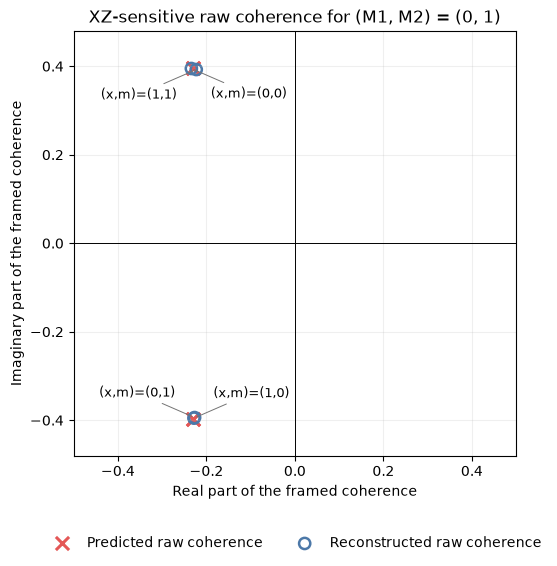

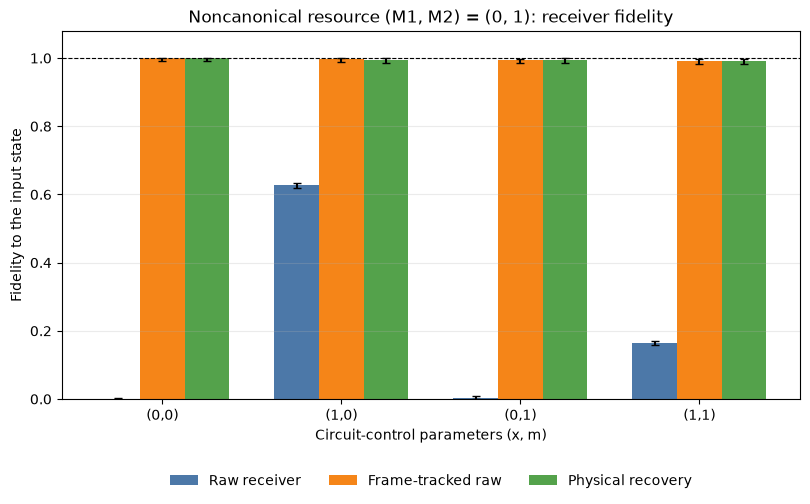

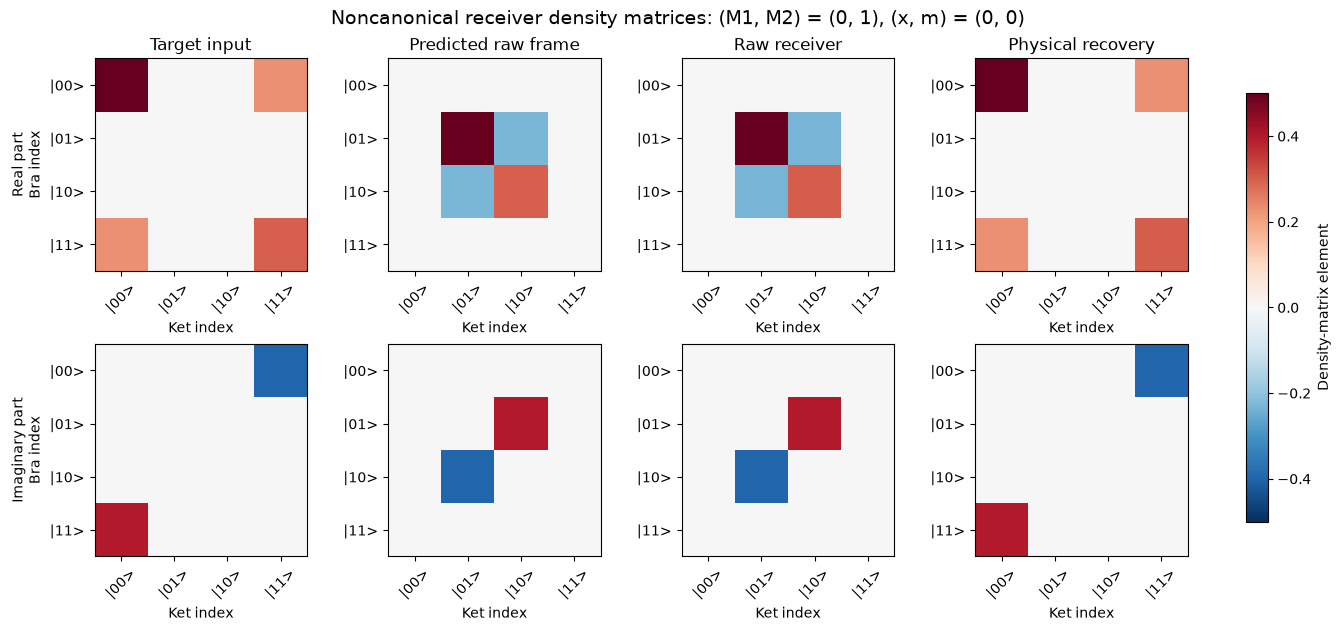

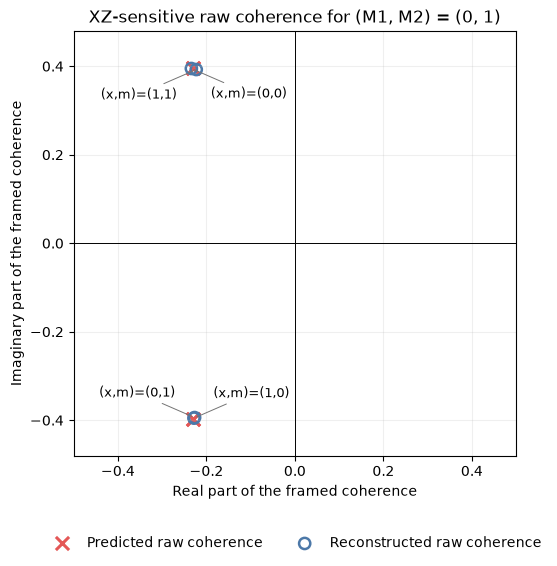

In [11]:
aer = AerSimulator()
aer_circuits = transpile(
    state_tomography_circuits,
    aer,
    optimization_level=1,
    seed_transpiler=RANDOM_SEED,
)
aer_result = aer.run(
    aer_circuits, shots=LOCAL_SHOTS, seed_simulator=RANDOM_SEED
).result()
aer_counts = [aer_result.get_counts(index) for index in range(len(aer_circuits))]

local_summary, local_densities, _ = summarize_state_tomography(
    state_records, aer_counts, bootstrap_samples=200
)
display(
    local_summary[
        [
            "resource",
            "case",
            "raw_fidelity_to_input",
            "raw_fidelity_to_predicted_frame",
            "frame_tracked_fidelity_to_input",
            "recovered_fidelity_to_input",
            "raw_coherence_phase_error_rad",
        ]
    ].round(4)
)
plot_fidelity_comparison(local_summary, prefix="ideal_noncanonical_M1_0_M2_1")
plot_density_matrices(
    local_densities, x=0, m=0, prefix="ideal_noncanonical_M1_0_M2_1"
)
plot_raw_coherence(local_summary, prefix="ideal_noncanonical_M1_0_M2_1")

Expected noiseless behavior:

- raw fidelity to the theorem-predicted noncanonical framed state is approximately 1;
- frame-tracked and physically recovered fidelities to the input are approximately 1;
- the reconstructed raw coherence agrees in both magnitude and phase with the XZ-sensitive
  prediction;
- the recovered coherence returns to the input value.

## 6. IBM Quantum account

The API key is requested through a hidden input and is not embedded in the notebook.
Run the credential-saving cell only once on a trusted computer. If credentials are
already saved, skip it.

In [16]:
from getpass import getpass

api_key = getpass("IBM Cloud API key: ")
instance = input("Instance CRN or name (leave blank for automatic selection): ").strip()

account_options = {
    "token": api_key,
    "channel": "ibm_quantum_platform",
    "set_as_default": True,
    "overwrite": True,
}
if instance:
    account_options["instance"] = instance

QiskitRuntimeService.save_account(**account_options)
del api_key, account_options
print("IBM Quantum credentials saved.")

IBM Cloud API key:  ········
Instance CRN or name (leave blank for automatic selection):  crn:v1:bluemix:public:quantum-computing:us-east:a/6bc69b01301a4661a7c5dbf6e86b9170:9bd45e3c-25c8-4526-aa65-a6a65bb4dc98::


IBM Quantum credentials saved.


In [17]:
service = QiskitRuntimeService()
backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=5,
)
print("Selected backend:", backend.name)
print("Pending jobs:", backend.status().pending_jobs)

Selected backend: ibm_phoenix
Pending jobs: 0


## 7. Compile and submit the noncanonical hardware tomography experiment

The compilation cell is free to run. The submission cell after it consumes QPU time.
With the default settings, one repeat contains 72 circuits x 4096 shots = 294,912 shots.
These 72 circuits test the selected noncanonical resource for four $(x,m)$ cases, two
modes (raw and physically recovered), and nine local Pauli measurement settings.

Increase `HARDWARE_REPEATS` only if independent run-to-run statistics are needed and the
account allocation permits them.

In [18]:
hardware_pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=3,
    seed_transpiler=RANDOM_SEED,
)
hardware_state_circuits = hardware_pm.run(state_tomography_circuits)

compile_rows = []
for record, compiled in zip(state_records, hardware_state_circuits):
    compile_rows.append(
        {
            **record,
            "depth": compiled.depth(),
            "two_qubit_gates": sum(
                count
                for gate, count in compiled.count_ops().items()
                if gate in {"cx", "cz", "ecr"}
            ),
            "operations": dict(compiled.count_ops()),
            "layout": repr(compiled.layout),
        }
    )

compilation_table = pd.DataFrame(compile_rows)
display(compilation_table[["x", "m", "mode", "basis_q4", "basis_q3", "depth", "two_qubit_gates"]].head(12))
compilation_table.drop(columns=["operations", "layout"]).to_csv(
    OUTPUT_DIR / "hardware_noncanonical_M1_0_M2_1_state_tomography_compilation.csv", index=False
)
print("Compiled circuits:", len(hardware_state_circuits))

,x,m,mode,basis_q4,basis_q3,depth,two_qubit_gates
0,0,0,raw,X,X,58,19
1,0,0,raw,X,Y,58,19
2,0,0,raw,X,Z,58,19
3,0,0,raw,Y,X,58,19
4,0,0,raw,Y,Y,57,19
5,0,0,raw,Y,Z,57,19
6,0,0,raw,Z,X,58,19
7,0,0,raw,Z,Y,57,19
8,0,0,raw,Z,Z,55,19
9,0,0,recovered,X,X,60,19


Compiled circuits: 72


**The next cell submits real QPU jobs.** Verify the backend, shot count, repeat count,
and account allocation before running it.

In [19]:
runtime_sampler = RuntimeSampler(mode=backend)
runtime_jobs = []
submitted_job_ids = []

for repeat_index in range(HARDWARE_REPEATS):
    job = runtime_sampler.run(hardware_state_circuits, shots=HARDWARE_SHOTS)
    runtime_jobs.append(job)
    submitted_job_ids.append(job.job_id())
    print(
        f"Submitted repeat {repeat_index + 1}/{HARDWARE_REPEATS}: "
        f"job_id={job.job_id()}, status={job.status()}"
    )

job_record_path = OUTPUT_DIR / "hardware_noncanonical_M1_0_M2_1_state_tomography_job_ids.json"
job_record_path.write_text(
    json.dumps(
        {
            "backend": backend.name,
            "shots_per_circuit": HARDWARE_SHOTS,
            "job_ids": submitted_job_ids,
            "submitted_utc": datetime.now(timezone.utc).isoformat(),
        },
        indent=2,
    ),
    encoding="utf-8",
)
print("Saved:", job_record_path.resolve())

Submitted repeat 1/1: job_id=daijlar9k43c73ag5m70, status=QUEUED
Saved: C:\Users\hideok34\noncanonical_resource_results\hardware_noncanonical_M1_0_M2_1_state_tomography_job_ids.json


If the kernel was restarted after submission, run the next cell to reconnect to the
saved jobs. Otherwise, skip it and continue to result retrieval.

In [20]:
job_record = json.loads(
    (OUTPUT_DIR / "hardware_noncanonical_M1_0_M2_1_state_tomography_job_ids.json").read_text(encoding="utf-8")
)
submitted_job_ids = job_record["job_ids"]
runtime_jobs = [service.job(job_id) for job_id in submitted_job_ids]
print("Reconnected jobs:", submitted_job_ids)

Reconnected jobs: ['daijlar9k43c73ag5m70']


In [21]:
hardware_repeated_counts = []
for repeat_index, job in enumerate(runtime_jobs, start=1):
    print(f"Waiting for repeat {repeat_index}: job_id={job.job_id()}")
    result = job.result()
    counts_list = [
        result[index].data.meas.get_counts() for index in range(len(state_records))
    ]
    hardware_repeated_counts.append(counts_list)
    print(f"Repeat {repeat_index} completed with {len(counts_list)} circuit results.")

pooled_hardware_counts = pool_repeated_counts(hardware_repeated_counts)
hardware_summary, hardware_densities, hardware_grouped_counts = summarize_state_tomography(
    state_records,
    pooled_hardware_counts,
    bootstrap_samples=BOOTSTRAP_SAMPLES,
)

display(
    hardware_summary[
        [
            "case",
            "raw_fidelity_to_input",
            "raw_fidelity_to_predicted_frame",
            "frame_tracked_fidelity_to_input",
            "recovered_fidelity_to_input",
            "recovered_code_population",
            "recovered_purity",
            "recovered_coherence_magnitude",
            "recovered_coherence_phase_rad",
        ]
    ].round(4)
)

Waiting for repeat 1: job_id=daijlar9k43c73ag5m70
Repeat 1 completed with 72 circuit results.


,case,raw_fidelity_to_input,raw_fidelity_to_predicted_frame,frame_tracked_fidelity_to_input,recovered_fidelity_to_input,recovered_code_population,recovered_purity,recovered_coherence_magnitude,recovered_coherence_phase_rad
0,"(0,0)",0.0238,0.9467,0.9467,0.9481,0.9663,0.9097,0.4191,-0.9078
1,"(1,0)",0.5046,0.8998,0.8998,0.9056,0.9375,0.8335,0.3924,-0.9020
2,"(0,1)",0.0253,0.9014,0.9014,0.9103,0.9365,0.8519,0.4014,-0.8258
3,"(1,1)",0.1971,0.9280,0.9280,0.9348,0.9626,0.8887,0.4120,-0.8783


Saved: C:\Users\hideok34\noncanonical_resource_results\hardware_noncanonical_M1_0_M2_1_state_tomography_summary.csv
Saved: C:\Users\hideok34\noncanonical_resource_results\hardware_noncanonical_M1_0_M2_1_state_tomography_summary.tex
Saved: C:\Users\hideok34\noncanonical_resource_results\hardware_noncanonical_M1_0_M2_1_state_tomography_counts.json
Saved: C:\Users\hideok34\noncanonical_resource_results\hardware_noncanonical_M1_0_M2_1_state_tomography_density_matrices.npz
Saved: C:\Users\hideok34\noncanonical_resource_results\hardware_noncanonical_M1_0_M2_1_state_tomography_metadata.json
Saved: C:\Users\hideok34\noncanonical_resource_results\hardware_noncanonical_M1_0_M2_1_fidelity_recovery.png
Saved: C:\Users\hideok34\noncanonical_resource_results\hardware_noncanonical_M1_0_M2_1_fidelity_recovery.pdf
Saved: C:\Users\hideok34\noncanonical_resource_results\hardware_noncanonical_M1_0_M2_1_density_matrices_x0_m0.png
Saved: C:\Users\hideok34\noncanonical_resource_results\hardware_noncanonical_

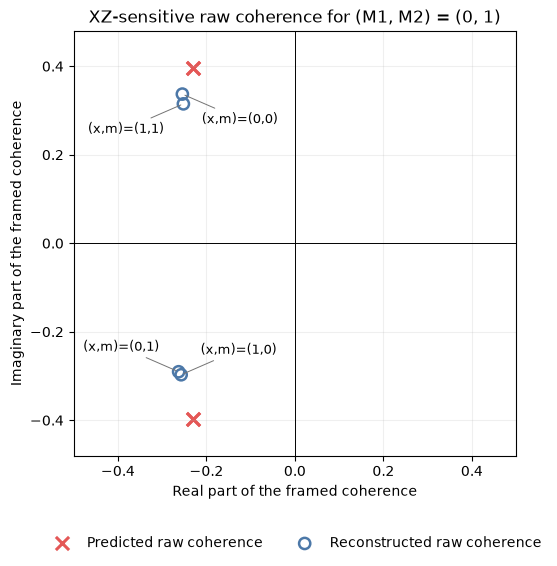

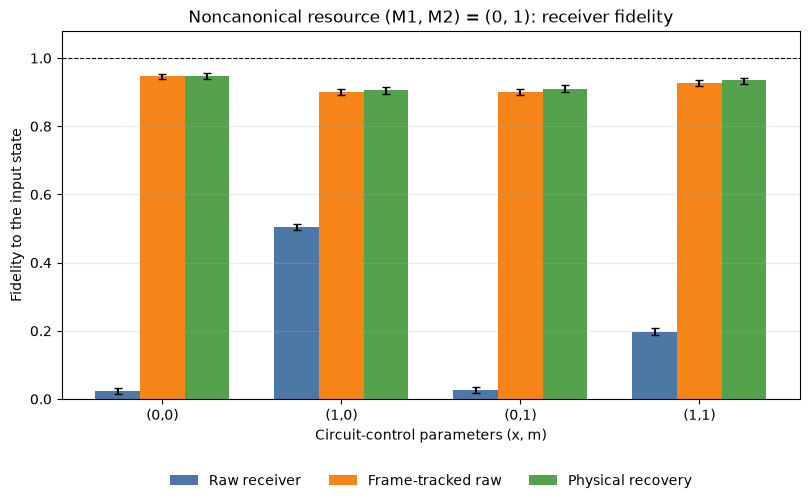

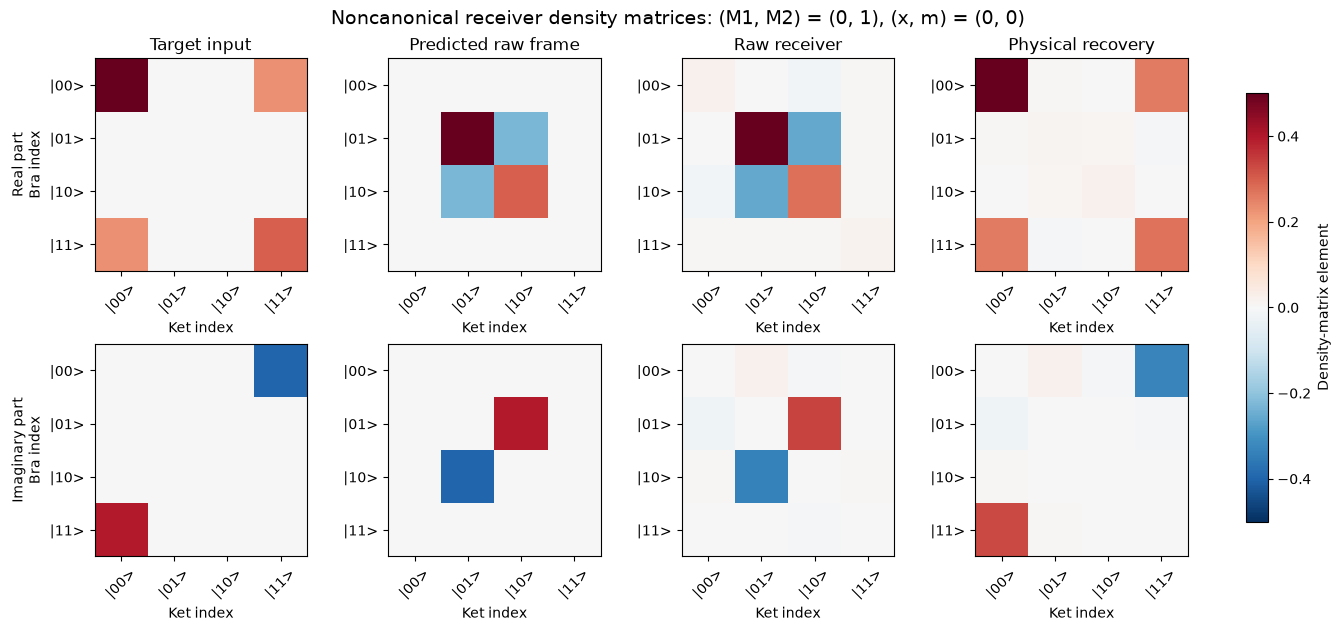

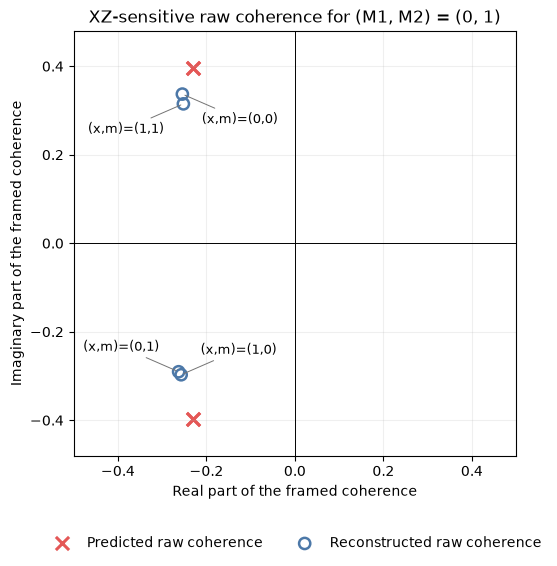

In [22]:
hardware_metadata = {
    "experiment": "Two-qubit receiver tomography for a noncanonical GHZ resource",
    "resource_M1": RESOURCE_M1,
    "resource_M2": RESOURCE_M2,
    "resource_state": "(|100> + (-1)^m |011>)/sqrt(2)",
    "resource_induced_receiver_factor_q3": "XZ",
    "raw_frame": "X4^(m xor x) tensor X3^(m xor M1 xor M2) Z3^M2",
    "inverse_recovery": "X4^(m xor x) tensor Z3^M2 X3^(m xor M1 xor M2)",
    "backend": backend.name,
    "job_ids": submitted_job_ids,
    "shots_per_circuit_per_repeat": HARDWARE_SHOTS,
    "repeats": len(hardware_repeated_counts),
    "circuits_per_repeat": len(state_records),
    "receiver_order": ["q4", "q3"],
    "input_state": "sqrt(0.7)|00> + exp(i*pi/3)*sqrt(0.3)|11>",
    "cases": [{"x": x, "m": m} for x, m in CASES],
    "tomography_bases": ["XX", "XY", "XZ", "YX", "YY", "YZ", "ZX", "ZY", "ZZ"],
    "reconstruction": "linear inversion plus nearest PSD trace-one projection",
    "uncertainty": f"multinomial bootstrap, {BOOTSTRAP_SAMPLES} resamples",
    "error_mitigation": "none",
    "qiskit_version": qiskit.__version__,
    "qiskit_ibm_runtime_version": qiskit_ibm_runtime.__version__,
    "analyzed_utc": datetime.now(timezone.utc).isoformat(),
}

save_state_results(
    prefix="hardware_noncanonical_M1_0_M2_1",
    summary=hardware_summary,
    densities=hardware_densities,
    records=state_records,
    repeated_counts=hardware_repeated_counts,
    metadata=hardware_metadata,
)
plot_fidelity_comparison(
    hardware_summary, prefix="hardware_noncanonical_M1_0_M2_1"
)
plot_density_matrices(
    hardware_densities,
    x=0,
    m=0,
    prefix="hardware_noncanonical_M1_0_M2_1",
)
plot_raw_coherence(
    hardware_summary, prefix="hardware_noncanonical_M1_0_M2_1"
)

## 8. Optional recovered logical-response tomography for the noncanonical resource

This optional experiment characterizes the recovered occupied-code-space response of
$(M_1,M_2)=(0,1)$ for one selected $(x,m)$ case using the logical inputs
$|0_L\rangle$, $|1_L\rangle$, $|+_L\rangle$, and $|+i_L\rangle$.

The output is a conditional Pauli response after projection onto
$\mathrm{span}\{|00\rangle,|11\rangle\}$. Code-space population is reported separately,
so leakage is not hidden. Because each reconstructed output is projected and normalized
separately, the identity-overlap values are descriptive diagnostics, not leakage-inclusive
process or average-gate fidelities of a reconstructed linear CPTP channel.

This section requires 36 additional circuits x 4096 shots. Run it only if needed.

In [23]:
PROCESS_CASE = (0, 0)
PROCESS_INPUTS = ("zero", "one", "plus", "plus_i")


def build_process_tomography_experiments(x, m):
    records = []
    circuits = []
    for state_label in PROCESS_INPUTS:
        base = build_transfer_circuit(
            x, m, recovered=True, state_label=state_label
        )
        for basis_q4, basis_q3 in product(TOMOGRAPHY_BASES, repeat=2):
            circuit = append_basis_measurement(base, basis_q4, basis_q3)
            circuit.name = (
                f"process_M1{RESOURCE_M1}_M2{RESOURCE_M2}_x{x}_m{m}_"
                f"{state_label}_{basis_q4}{basis_q3}"
            )
            records.append(
                {
                    "logical_input": state_label,
                    "M1": RESOURCE_M1,
                    "M2": RESOURCE_M2,
                    "x": x,
                    "m": m,
                    "mode": "recovered",
                    "basis_q4": basis_q4,
                    "basis_q3": basis_q3,
                    "circuit_name": circuit.name,
                }
            )
            circuits.append(circuit)
    return records, circuits


process_x, process_m = PROCESS_CASE
process_records, process_circuits = build_process_tomography_experiments(
    process_x, process_m
)
print("Selected resource:", RESOURCE_LABEL)
print("Logical-response tomography circuits:", len(process_circuits))

Selected resource: M1=0, M2=1
Logical-response tomography circuits: 36


In [24]:
def logical_density_from_receiver(receiver_density):
    code_indices = [0, 3]
    code_block = receiver_density[np.ix_(code_indices, code_indices)]
    code_population = float(np.real(np.trace(code_block)))
    if code_population <= 0:
        raise ValueError("Non-positive reconstructed code-space population.")
    logical_density = project_to_density_matrix(code_block / code_population)
    return logical_density, code_population


def bloch_vector(logical_density):
    return np.array(
        [
            np.real(np.trace(logical_density @ X2)),
            np.real(np.trace(logical_density @ Y2)),
            np.real(np.trace(logical_density @ Z2)),
        ]
    )


def reconstruct_logical_ptm(process_records, counts_list):
    groups = group_tomography_counts(
        process_records, counts_list, extra_keys=("logical_input",)
    )
    receiver_states = {}
    logical_states = {}
    code_populations = {}
    for label in PROCESS_INPUTS:
        _, receiver, _ = reconstruct_two_qubit_state(
            groups[(label, process_x, process_m, "recovered")]
        )
        logical, population = logical_density_from_receiver(receiver)
        receiver_states[label] = receiver
        logical_states[label] = logical
        code_populations[label] = population

    r_zero = bloch_vector(logical_states["zero"])
    r_one = bloch_vector(logical_states["one"])
    r_plus = bloch_vector(logical_states["plus"])
    r_plus_i = bloch_vector(logical_states["plus_i"])

    translation = (r_zero + r_one) / 2
    transfer = np.column_stack(
        [
            r_plus - translation,
            r_plus_i - translation,
            (r_zero - r_one) / 2,
        ]
    )
    ptm = np.zeros((4, 4), dtype=float)
    ptm[0, 0] = 1.0
    ptm[1:, 0] = translation
    ptm[1:, 1:] = transfer

    process_fidelity = float(np.clip((1 + np.trace(transfer)) / 4, 0, 1))
    average_gate_fidelity = float(np.clip((2 * process_fidelity + 1) / 3, 0, 1))
    return {
        "ptm": ptm,
        "process_fidelity_to_identity": process_fidelity,
        "average_gate_fidelity_to_identity": average_gate_fidelity,
        "receiver_states": receiver_states,
        "logical_states": logical_states,
        "code_populations": code_populations,
        "groups": groups,
    }


def plot_logical_ptm(process_analysis, prefix):
    measured = process_analysis["ptm"]
    ideal = np.eye(4)
    labels = ["I", "X", "Y", "Z"]
    fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.8), constrained_layout=True)
    for ax, matrix, title in zip(
        axes, (ideal, measured), ("Ideal identity channel", "Recovered channel estimate")
    ):
        image = ax.imshow(matrix, cmap="RdBu_r", vmin=-1, vmax=1)
        ax.set_xticks(range(4), labels)
        ax.set_yticks(range(4), labels)
        ax.set_xlabel("Input Pauli operator")
        ax.set_ylabel("Output Pauli operator")
        ax.set_title(title)
        for row in range(4):
            for column in range(4):
                color = "white" if abs(matrix[row, column]) > 0.55 else "black"
                ax.text(
                    column,
                    row,
                    f"{matrix[row, column]:.2f}",
                    ha="center",
                    va="center",
                    color=color,
                    fontsize=9,
                )
    fig.colorbar(image, ax=axes, shrink=0.85, label="Pauli transfer coefficient")
    fig.suptitle(
        f"Noncanonical recovered logical response for (M1, M2) = (0, 1), (x, m) = ({process_x}, {process_m})"
    )
    save_figure(fig, f"{prefix}_logical_process_ptm_x{process_x}_m{process_m}")
    return fig

Local process fidelity to identity: 0.99709
Local average gate fidelity to identity: 0.99806
Saved: C:\Users\hideok34\noncanonical_resource_results\ideal_noncanonical_M1_0_M2_1_logical_process_ptm_x0_m0.png
Saved: C:\Users\hideok34\noncanonical_resource_results\ideal_noncanonical_M1_0_M2_1_logical_process_ptm_x0_m0.pdf


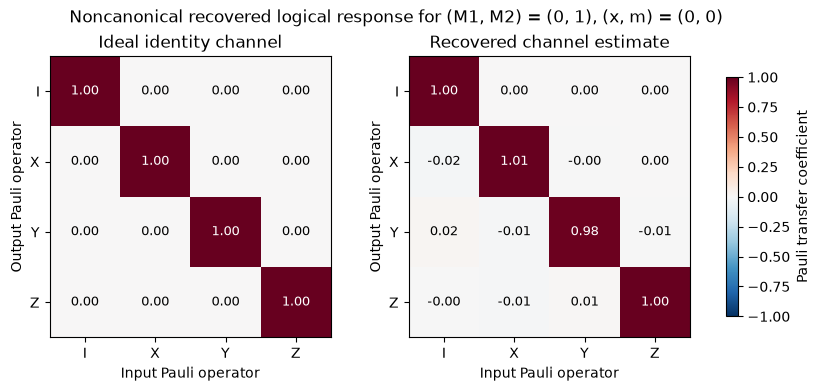

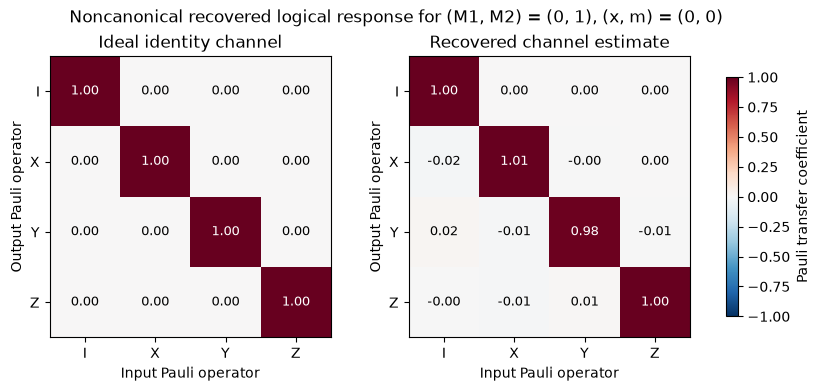

In [25]:
# Local validation of the optional logical-process analysis.
process_aer = AerSimulator()
process_aer_circuits = transpile(
    process_circuits,
    process_aer,
    optimization_level=1,
    seed_transpiler=RANDOM_SEED,
)
process_aer_result = process_aer.run(
    process_aer_circuits,
    shots=LOCAL_SHOTS,
    seed_simulator=RANDOM_SEED,
).result()
process_aer_counts = [
    process_aer_result.get_counts(index)
    for index in range(len(process_aer_circuits))
]
local_process_analysis = reconstruct_logical_ptm(
    process_records, process_aer_counts
)
print(
    "Local process fidelity to identity:",
    round(local_process_analysis["process_fidelity_to_identity"], 5),
)
print(
    "Local average gate fidelity to identity:",
    round(local_process_analysis["average_gate_fidelity_to_identity"], 5),
)
plot_logical_ptm(local_process_analysis, prefix="ideal_noncanonical_M1_0_M2_1")

**The next cell submits the optional logical-process tomography job to the real QPU.**

In [26]:
process_hardware_circuits = hardware_pm.run(process_circuits)
process_sampler = RuntimeSampler(mode=backend)
process_job = process_sampler.run(
    process_hardware_circuits, shots=HARDWARE_SHOTS
)
process_job_id = process_job.job_id()
process_job_path = OUTPUT_DIR / "hardware_noncanonical_M1_0_M2_1_logical_response_job_id.json"
process_job_path.write_text(
    json.dumps(
        {
            "backend": backend.name,
            "job_id": process_job_id,
            "shots_per_circuit": HARDWARE_SHOTS,
            "case": {"x": process_x, "m": process_m},
            "submitted_utc": datetime.now(timezone.utc).isoformat(),
        },
        indent=2,
    ),
    encoding="utf-8",
)
print("Process-tomography job ID:", process_job_id)
print("Status:", process_job.status())
print("Saved:", process_job_path.resolve())

Process-tomography job ID: daijma39k43c73ag5n40
Status: QUEUED
Saved: C:\Users\hideok34\noncanonical_resource_results\hardware_noncanonical_M1_0_M2_1_logical_response_job_id.json


,case,process_fidelity_to_identity,average_gate_fidelity_to_identity,code_population_zero,code_population_one,code_population_plus,code_population_plus_i
0,"(0,0)",0.9652,0.9768,0.9629,0.9487,0.9583,0.9612


Saved: C:\Users\hideok34\noncanonical_resource_results\hardware_noncanonical_M1_0_M2_1_logical_process_ptm_x0_m0.png
Saved: C:\Users\hideok34\noncanonical_resource_results\hardware_noncanonical_M1_0_M2_1_logical_process_ptm_x0_m0.pdf


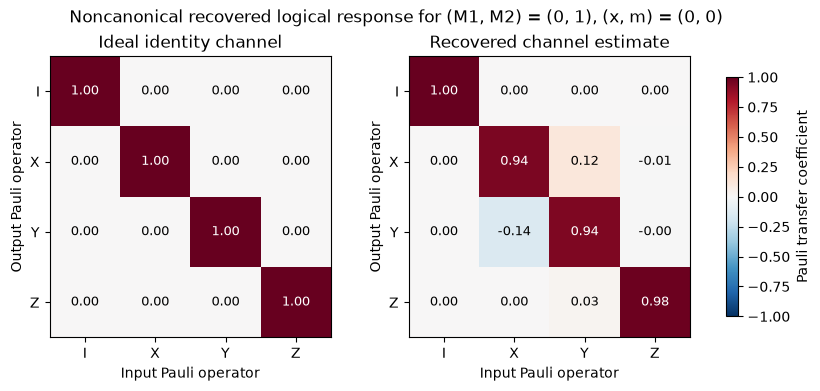

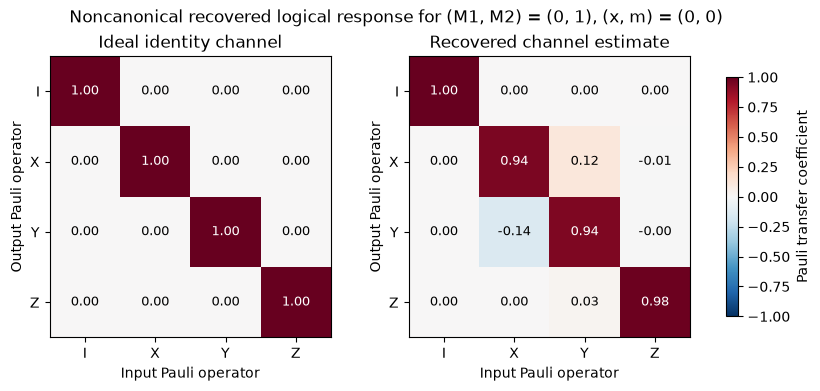

In [27]:
# To reconnect after a kernel restart, uncomment the following lines.
# process_job_record = json.loads(
#     (OUTPUT_DIR / "hardware_noncanonical_M1_0_M2_1_logical_response_job_id.json").read_text(encoding="utf-8")
# )
# process_job = service.job(process_job_record["job_id"])

process_result = process_job.result()
process_hardware_counts = [
    process_result[index].data.meas.get_counts()
    for index in range(len(process_records))
]
hardware_process_analysis = reconstruct_logical_ptm(
    process_records, process_hardware_counts
)

process_summary = pd.DataFrame(
    [
        {
            "case": f"({process_x},{process_m})",
            "process_fidelity_to_identity": hardware_process_analysis[
                "process_fidelity_to_identity"
            ],
            "average_gate_fidelity_to_identity": hardware_process_analysis[
                "average_gate_fidelity_to_identity"
            ],
            **{
                f"code_population_{label}": population
                for label, population in hardware_process_analysis[
                    "code_populations"
                ].items()
            },
        }
    ]
)
display(process_summary.round(4))
process_summary.to_csv(
    OUTPUT_DIR / "hardware_noncanonical_M1_0_M2_1_logical_response_summary.csv", index=False
)
np.savetxt(
    OUTPUT_DIR / "hardware_noncanonical_M1_0_M2_1_logical_response_ptm.csv",
    hardware_process_analysis["ptm"],
    delimiter=",",
    header="I,X,Y,Z",
    comments="",
)
process_counts_output = [
    {**record, "counts": normalized_two_bit_counts(counts)}
    for record, counts in zip(process_records, process_hardware_counts)
]
(OUTPUT_DIR / "hardware_noncanonical_M1_0_M2_1_logical_response_counts.json").write_text(
    json.dumps(process_counts_output, indent=2), encoding="utf-8"
)
plot_logical_ptm(hardware_process_analysis, prefix="hardware_noncanonical_M1_0_M2_1")

## 9. Interpretation checklist for the manuscript

When reporting the new hardware results, state explicitly that:

- the experimentally tested noncanonical resource is $(M_1,M_2)=(0,1)$;
- the prepared resource is $(|100\rangle+(-1)^m|011\rangle)/\sqrt{2}$;
- its resource-dependent receiver contribution is $XZ$ on $q_3$;
- all four $(x,m)$ sectors use the same nonsymmetric complex input;
- tomography uses nine local Pauli settings on receiver qubits $(q_4,q_3)$;
- raw-state fidelity is evaluated against the family-wide theorem prediction;
- recovery is tested by both explicit gates and software frame tracking;
- the XZ-sensitive raw coherence is compared in magnitude and phase;
- density matrices use a PSD trace-one projection after linear inversion;
- uncertainty bars are multinomial bootstrap intervals;
- results are unmitigated unless a separately documented mitigation method is added;
- any conditional logical-response diagnostic reports code-space population separately and
  is not described as a leakage-inclusive CPTP process fidelity.